In [2]:
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt

##### Постановка задачи

$$
u_{tt} = a^2 \Delta u
$$

Начальные условия:

$$
\begin{cases}
u(x,y,0) = \delta(x)\delta(y), \\
u_t(x,y,0) = 0.
\end{cases}
$$

Область определения - квадрат с началом координат в центре, задача решается до достижения возмущением границ квадрата, то есть решение совпадает с решением на бесконечной плоскости:

$$
-l < x < l, \qquad
-l < y < l, \qquad
t < \dfrac{l}{a}.
$$

##### Параметры задачи

In [3]:
a = 1
l = 3

n = 101

##### Вычисление необходимых параметров и задание переменных

Здесь аппроксимация дельта функции выполняется при помощи следующих функций:

$$
\begin{align}
U_0(x, y, 0) &=
\begin{cases}
\dfrac{1}{4 \varepsilon^2} \left(1 + \cos\left(\dfrac{\pi x}{\varepsilon}\right)\right)\left(1 + \cos\left(\dfrac{\pi y}{\varepsilon}\right)\right), & 0 \le r \le \varepsilon \\
0, & r > \varepsilon
\end{cases}\\

U_1(x, y, 0) &= \dfrac{1}{2 \pi \sigma^2}\exp\left(-\dfrac{x^2 + y^2}{2\sigma^2}\right) \\

U_2(x, y, 0) &= 
\begin{cases}
A \left(1 - \dfrac{r^2}{\varepsilon^2}\right)^3, & 0 \le r \le \varepsilon, \\
0, & r > \varepsilon
\end{cases}
\end{align}
$$

Коэффициент А рассчитывается исходя из того, что:
$$
2\pi \int_0^\varepsilon A \left(1 - \frac{r^2}{\varepsilon^2} \right)^3 r \, dr = 1.
$$

Сделаем замену $u = r^2/\varepsilon^2 \Rightarrow r\,dr = \frac{\varepsilon^2}{2}\, du$:

$$
\int_0^\varepsilon r \left(1 - \frac{r^2}{\varepsilon^2}\right)^3 dr = \frac{\varepsilon^2}{2} \int_0^1 (1-u)^3 du = \frac{\varepsilon^2}{2} \cdot \frac{1}{4} = \frac{\varepsilon^2}{8}.
$$

Следовательно, нормировочный коэффициент:

$$
2 \pi A \cdot \frac{\varepsilon^2}{8} = 1 \quad \Rightarrow \quad A = \frac{4}{\pi \varepsilon^2}.
$$

In [4]:
T = l/a
h = 2*l/n
t = h/(8*a)
eps = 6*h
sigma = h

time = 0

x = np.linspace(-l, l, n)
y = np.linspace(-l, l, n)
X, Y = np.meshgrid(x, y)
r = np.sqrt(X**2 + Y**2)

mask = (np.abs(X) <= eps) & (np.abs(Y) <= eps)

U01 = np.zeros((n,n))
U01[mask] = (1 / eps**2) * (1 + np.cos(np.pi * X[mask]/eps))/2 * (1 + np.cos(np.pi * Y[mask]/eps))/2

U02 = np.zeros((n,n))
U02 = (1 / (2 * np.pi * sigma**2)) * np.exp(-((X**2 + Y**2)/(2 * sigma**2)))

U03 = np.zeros((n,n))
U03[mask] = (4 / (np.pi * eps**2)) * (1 - (X[mask]**2 + Y[mask]**2)/(eps ** 2))

Ut = np.zeros((n,n))

U02 /= (np.sum(U02))

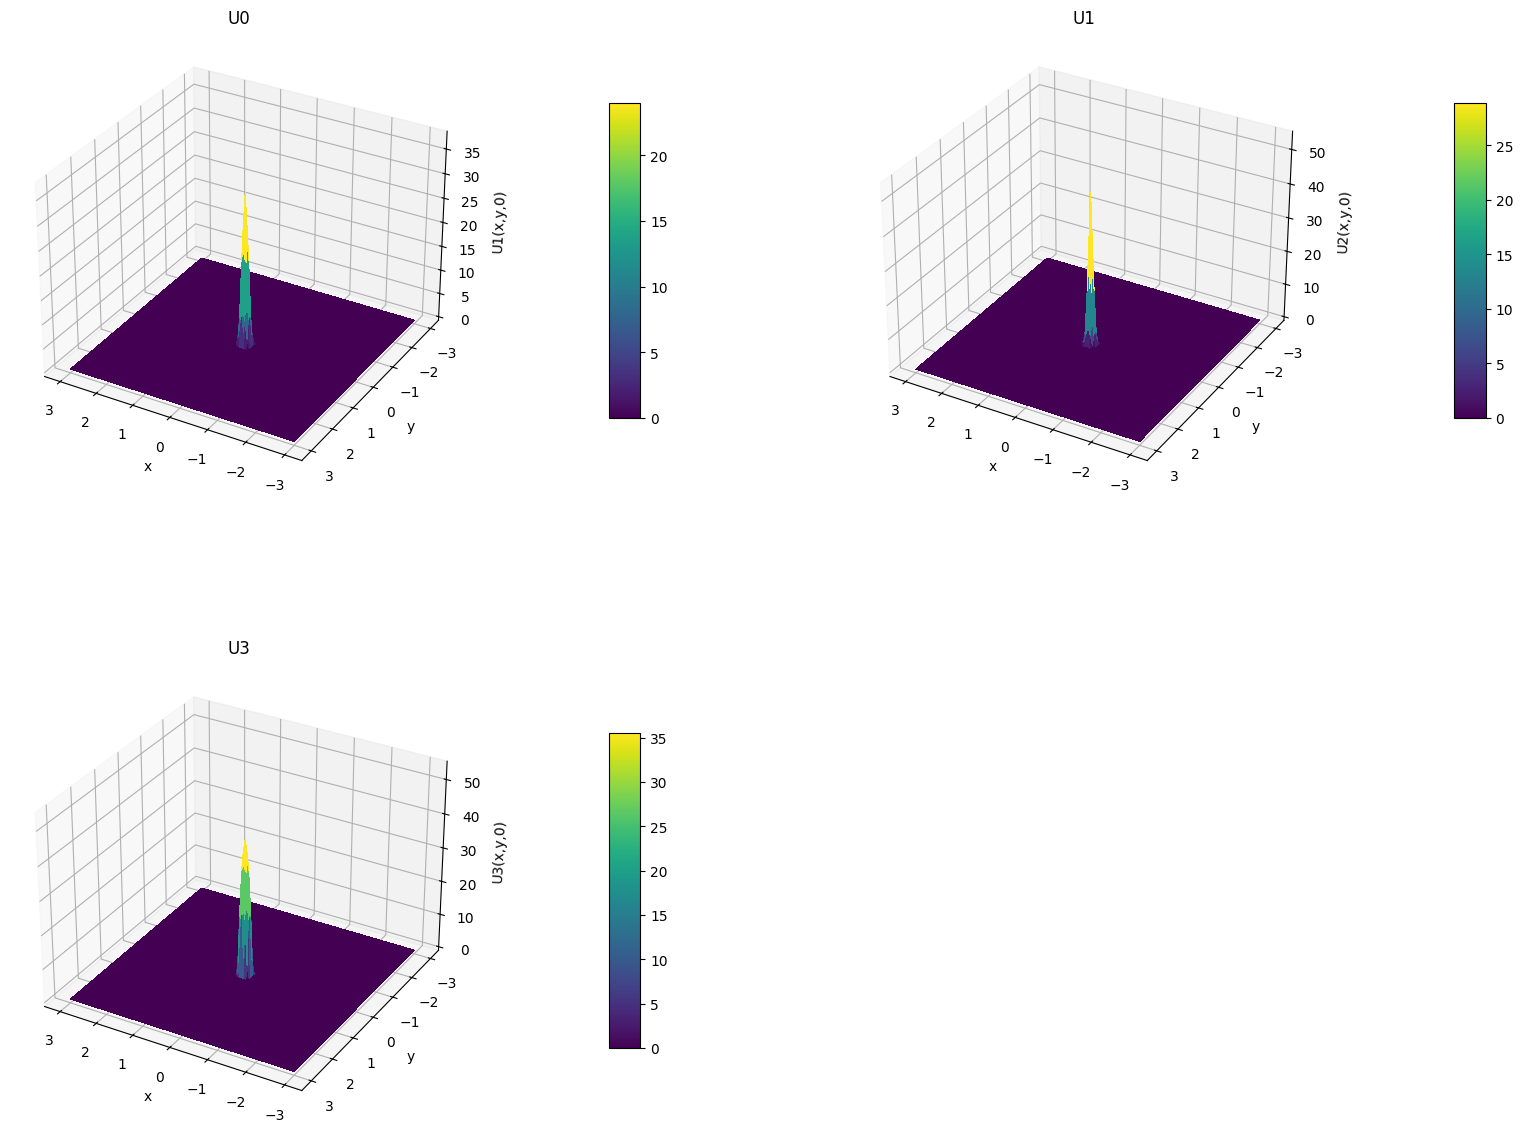

In [64]:
fig = plt.figure(figsize=(20, 15))
ax1 = fig.add_subplot(221, projection='3d')
surf1 = ax1.plot_surface(X, Y, U01,
                       cmap='viridis',
                       rstride=1, cstride=1,
                       linewidth=0,
                       antialiased=False)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('U1(x,y,0)')
ax1.set_title('U0')
fig.colorbar(surf1, ax = ax1, shrink=0.6, aspect=10, pad=0.2)
ax1.view_init(elev=30, azim=120)
ax1.set_zlim(0, U01.max() * 1.2)

ax2 = fig.add_subplot(222, projection='3d')
surf2 = ax2.plot_surface(X, Y, U02,
                       cmap='viridis',
                       rstride=1, cstride=1,
                       linewidth=0,
                       antialiased=False)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('U2(x,y,0)')
ax2.set_title('U1')
fig.colorbar(surf2, shrink=0.6, aspect=10, pad= 0.2)
ax2.view_init(elev=30, azim=120)
ax2.set_zlim(0, U02.max() * 1.2)

ax2 = fig.add_subplot(223, projection='3d')
surf2 = ax2.plot_surface(X, Y, U03,
                       cmap='viridis',
                       rstride=1, cstride=1,
                       linewidth=0,
                       antialiased=False)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('U3(x,y,0)')
ax2.set_title('U3')
fig.colorbar(surf2, shrink=0.6, aspect=10, pad= 0.2)
ax2.view_init(elev=30, azim=120)
ax2.set_zlim(0, U02.max() * 1.2)

plt.show()

##### Аналитическое решение

Аналитическое решение задается при помощи формулы Пуассона:

$$
U(x, y, t) = \frac{1}{2\pi a}\int_{|d-\xi| < at}\frac{U_1(\xi_1, \xi_2)}{\sqrt{(at)^2 - |d - \xi|^2}}d\xi_1d\xi_2 + \frac{\partial}{\partial t}\left(\frac{1}{2\pi a}\int_{|d-\xi| < at}\frac{U_0(\xi_1,\xi_2)}{\sqrt{(at)^2-|d-\xi|^2}}d\xi_1d\xi_2\right)
$$

где

$$
\begin{align}
U(x, y, 0) &= U_0(x, y) \in \mathrm{C}^3(\mathbb{R}^2), \\
U_t(x, y, 0) &= U_1(x,y) \in \mathrm{C}^2(\mathbb{R}^2), \\
d &\text{ --- точка наблюдения.}
\end{align}
$$

В текущей задаче данные условия выполнимы только при $U_0 = U_2$.
Также можно заметить, что в текущей задаче $U_1(x,y) = 0$, получаем:

$$
U(x, y, t) = \frac{\partial}{\partial t}\left(\frac{1}{2\pi a}\int_{|d-\xi| < at}\frac{U_0(\xi_1,\xi_2)}{\sqrt{(at)^2-|d-\xi|^2}}d\xi_1d\xi_2\right)
$$

Посчитаем это выражение для исходной задачи:

$$
\begin{align}
U(x, y, t) &= \frac{\partial}{\partial t}\left(\frac{1}{2\pi a}\int_{|d-\xi| < at}\frac{\delta(x)\delta(y)}{\sqrt{(at)^2-|d-\xi|^2}}d\xi_1d\xi_2\right) \\

U(x, y, t) &= 
\begin{cases}
\dfrac{1}{2\pi a}\dfrac{\partial}{\partial t}\left(\dfrac{1}{\sqrt{(at)^2 - x^2 - y^2}}\right), & \sqrt{x^2 + y^2} < at \\
0, &\text{иначе.}
\end{cases}\\

U(x, y, t) &=
\begin{cases}
\dfrac{1}{\pi}\cdot\dfrac{t}{((at)^2 - x^2 - y^2)^{3/2}}, & \sqrt{x^2 + y^2} < at \\
0, &\text{иначе.}
\end{cases}\\
\end{align}
$$

In [5]:
U_analytical = np.zeros((n,n))
time = 0


plt.ion()
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, Y, U_analytical,
                    cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('U(x,y,t)')
ax.set_zlim(0, 10)
ax.set_title('Аналитическая U')
ax.view_init(elev=30, azim=120)

ax1 = fig.add_subplot(122)
ax1.set_ylim(0,1.5)
ax1.set_xlabel('r')
ax1.set_ylabel('U(r,t)')
ax1.set_title('Аналитическая U - срез по радиусу')

ax2 = fig.add_subplot(1,3,3)
ax2.axis('off')

N = n//2
surf1, = ax1.plot(r[N,N:], U_analytical[N,N:])


display(fig)

while time < T:
    mask = r < a * time
    U_analytical[mask] = (1 / np.pi) * (time / np.power((a * time)**2 - X[mask]**2 - Y[mask]**2, 3/2))
    U_analytical[U_analytical > 10] = 10
    
    surf.remove()
    surf = ax.plot_surface(X, Y, U_analytical, cmap='viridis')

    surf1.set_ydata(U_analytical[N, N:])

    ax2.clear()
    ax2.axis('off')
    ax2.text(0, 0.5, f"time = {time:.2f}\n(a*time)^2 = {(a*time)**2:.2f}\nU(center) = {U_analytical[n//2,n//2]:.2f}", 
            fontsize=12)
    clear_output(wait=True)
    display(fig)
    plt.pause(0.05)
    
    time += t
plt.ioff()

KeyboardInterrupt: 

##### Численное решение при помощи $U_1, U_2, U_3$

Рекуррентная формула:

$$
\begin{align}
\frac{u_{i,j}^{n+1} - 2 u_{i,j}^{n} + u_{i,j}^{n-1}}{\Delta t^2} &=
a^2 \left(
\frac{u_{i+1,j}^{n} - 2 u_{i,j}^{n} + u_{i-1,j}^{n}}{\Delta x^2} +
\frac{u_{i,j+1}^{n} - 2 u_{i,j}^{n} + u_{i,j-1}^{n}}{\Delta y^2}
\right) \\
u_{i,j}^{n+1} &= 2u_{i,j}^{n} - u_{i,j}^{n-1} + \left(\dfrac{a\tau}{h}\right)^2\left(u_{i+1,j}^{n} + u_{i-1,j}^{n} + u_{i,j+1}^{n} + u_{i,j-1}^{n} - 4u_{i,j}^{n}\right)
\end{align}
$$

Формула для первого слоя:
$$
\begin{align}
\dot{u}_{i,j}^{0} &= 0 = \dfrac{u_{i,j}^{1} - u_{i,j}^{-1}}{2\tau} \\

u_{i,j}^{-1} &= u_{i,j}^{1} - 2\tau\dot{u}_{i,j}^{0} \\

u_{i,j}^{1} &= 2u_{i,j}^{0} - \left(u_{i,j}^{1} - 2\tau\dot{u}_{i,j}^{0}\right) + \left(\dfrac{a\tau}{h}\right)^2\left(u_{i+1,j}^{0} + u_{i-1,j}^{0} + u_{i,j+1}^{0} + u_{i,j-1}^{0} - 4u_{i,j}^{0}\right) \\

u_{i,j}^{1} &= u_{i,j}^{0} + \left(\dfrac{a^2\tau^2}{2h^2}\right)\left(u_{i+1,j}^{0} + u_{i-1,j}^{0} + u_{i,j+1}^{0} + u_{i,j-1}^{0} - 4u_{i,j}^{0}\right)
\end{align}
$$

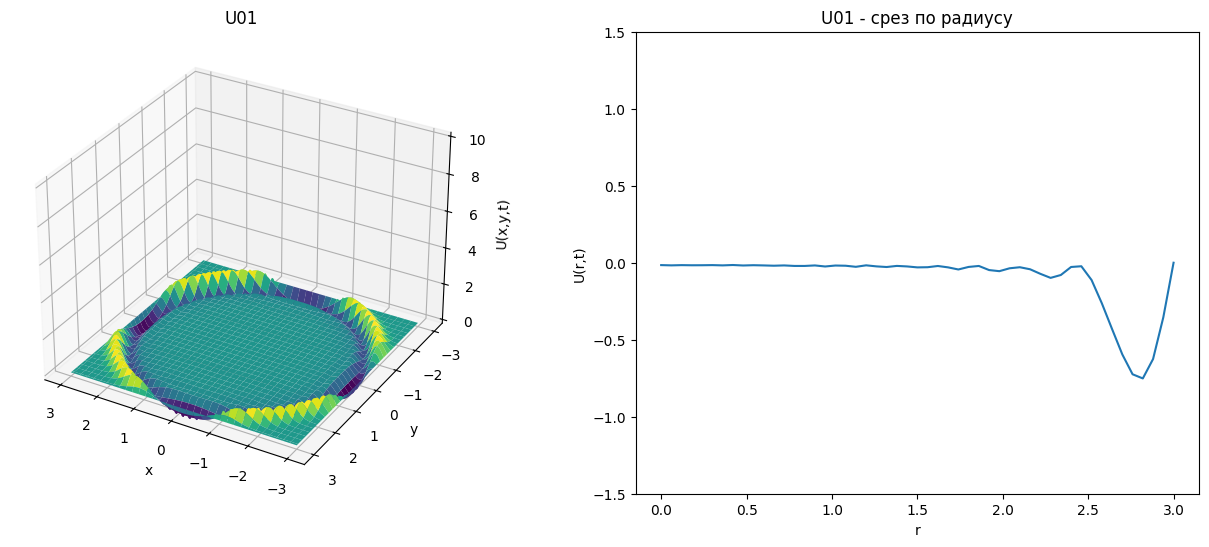

In [68]:
time = 0
U = np.zeros((n,n,3))
U[:,:,1] = U01
U[1:-1,1:-1,0] = U[1:-1,1:-1,1] + (((a * t)**2)/(2 * h**2)) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])


plt.ion()
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, Y, U[:,:,0],
                    cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('U(x,y,t)')
ax.set_zlim(0, 10)
ax.set_title('U01')
ax.view_init(elev=30, azim=120)

ax1 = fig.add_subplot(122)
ax1.set_ylim(-1.5,1.5)
ax1.set_xlabel('r')
ax1.set_ylabel('U(r,t)')
ax1.set_title('U01 - срез по радиусу')

# ax2 = fig.add_subplot(1,3,3)
# ax2.axis('off')

N = n//2
surf1, = ax1.plot(r[N,N:], U[N,N:,0])


while time < T:
    U[:,:,2] = U[:,:,1]
    U[:,:,1] = U[:,:,0]
    U[1:-1,1:-1,0] = 2*U[1:-1,1:-1,1] - U[1:-1,1:-1,2] + (((a * t)/(h))**2) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])

    surf.remove()
    surf = ax.plot_surface(X, Y, U[:,:,0], cmap='viridis')

    surf1.set_ydata(U[N, N:,0])

    # ax2.clear()
    # ax2.axis('off')
    # ax2.text(0, 0.5, f"time = {time:.2f}\n(a*time)^2 = {(a*time)**2:.2f}\nU(center) = {U[n//2,n//2,0]:.2f}", 
    #         fontsize=12)
    clear_output(wait=True)
    display(fig)
    plt.pause(0.05)
    
    time += t

plt.ioff()

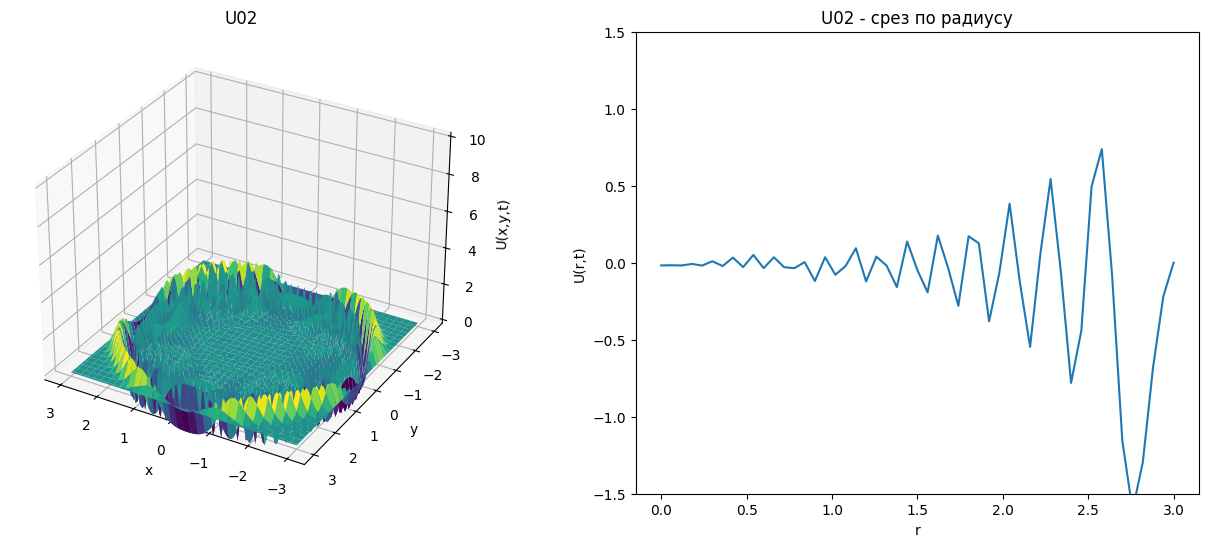

In [ ]:
time = 0
U = np.zeros((n,n,3))
U[:,:,1] = U02
U[1:-1,1:-1,0] = U[1:-1,1:-1,1] + (((a * t)**2)/(2 * h**2)) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])


plt.ion()
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, Y, U[:,:,0],
                    cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('U(x,y,t)')
ax.set_zlim(0, 10)
ax.set_title('U02')
ax.view_init(elev=30, azim=120)

ax1 = fig.add_subplot(122)
ax1.set_ylim(-1.5,1.5)
ax1.set_xlabel('r')
ax1.set_ylabel('U(r,t)')
ax1.set_title('U02 - срез по радиусу')

# ax2 = fig.add_subplot(1,3,3)
# ax2.axis('off')

N = n//2
surf1, = ax1.plot(r[N,N:], U[N,N:,0])


while time < T:
    U[:,:,2] = U[:,:,1]
    U[:,:,1] = U[:,:,0]
    U[1:-1,1:-1,0] = 2*U[1:-1,1:-1,1] - U[1:-1,1:-1,2] + (((a * t)/(h))**2) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])

    surf.remove()
    surf = ax.plot_surface(X, Y, U[:,:,0], cmap='viridis')

    surf1.set_ydata(U[N, N:,0])

    # ax2.clear()
    # ax2.axis('off')
    # ax2.text(0, 0.5, f"time = {time:.2f}\n(a*time)^2 = {(a*time)**2:.2f}\nU(center) = {U[n//2,n//2,0]:.2f}", 
    #         fontsize=12)
    clear_output(wait=True)
    display(fig)
    plt.pause(0.05)
    
    time += t

plt.ioff()

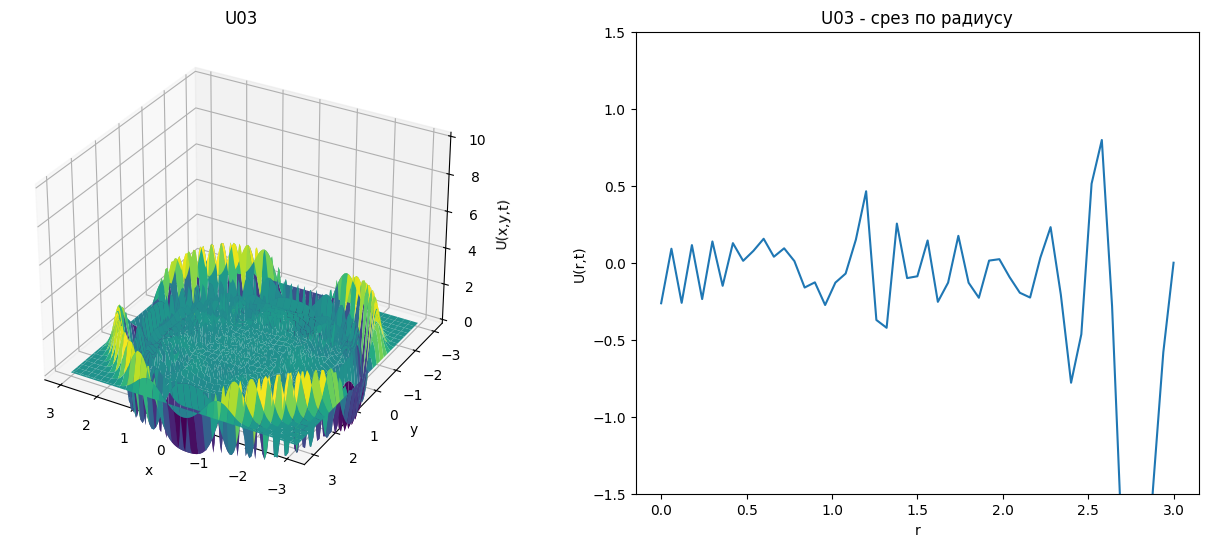

In [ ]:
time = 0
U = np.zeros((n,n,3))
U[:,:,1] = U03
U[1:-1,1:-1,0] = U[1:-1,1:-1,1] + (((a * t)**2)/(2 * h**2)) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])


plt.ion()
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(X, Y, U[:,:,0],
                    cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('U(x,y,t)')
ax.set_zlim(0, 10)
ax.set_title('U03')
ax.view_init(elev=30, azim=120)

ax1 = fig.add_subplot(122)
ax1.set_ylim(-1.5,1.5)
ax1.set_xlabel('r')
ax1.set_ylabel('U(r,t)')
ax1.set_title('U03 - срез по радиусу')

# ax2 = fig.add_subplot(1,3,3)
# ax2.axis('off')

N = n//2
surf1, = ax1.plot(r[N,N:], U[N,N:,0])


while time < T:
    U[:,:,2] = U[:,:,1]
    U[:,:,1] = U[:,:,0]
    U[1:-1,1:-1,0] = 2*U[1:-1,1:-1,1] - U[1:-1,1:-1,2] + (((a * t)/(h))**2) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])

    surf.remove()
    surf = ax.plot_surface(X, Y, U[:,:,0], cmap='viridis')

    surf1.set_ydata(U[N, N:,0])

    # ax2.clear()
    # ax2.axis('off')
    # ax2.text(0, 0.5, f"time = {time:.2f}\n(a*time)^2 = {(a*time)**2:.2f}\nU(center) = {U[n//2,n//2,0]:.2f}", 
    #         fontsize=12)
    clear_output(wait=True)
    display(fig)
    plt.pause(0.05)
    
    time += t

plt.ioff()

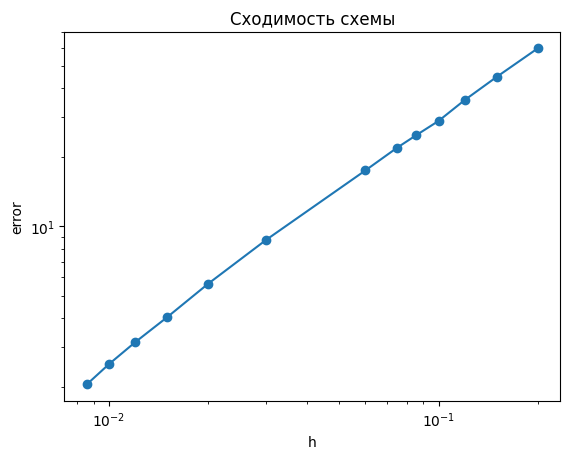

Порядок схемы p = 1.0570112093176334


In [ ]:
nn = [31, 41, 51, 61, 71, 81, 101,201,301,401,501,601,701]
hh = []
err = []
sigma = h
for n in nn:
    U = np.zeros((n,n,3))
    U_analytical = np.zeros((n,n))
    time = 0
    x = np.linspace(-l, l, n)
    y = np.linspace(-l, l, n)
    X, Y = np.meshgrid(x, y)
    r = np.sqrt(X**2 + Y**2)

    h = x[1] - x[0]
    t = h/(2*a)

    U02 = np.zeros((n,n))
    U02 = (1 / (2 * np.pi * sigma**2)) * np.exp(-((X**2 + Y**2)/(2 * sigma**2)))
    U[:,:,1] = U02
    U[1:-1,1:-1,0] = U[1:-1,1:-1,1] + (((a * t)**2)/(2 * h**2)) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])
    while time < T:
        U[:,:,2] = U[:,:,1]
        U[:,:,1] = U[:,:,0]
        U[1:-1,1:-1,0] = 2*U[1:-1,1:-1,1] - U[1:-1,1:-1,2] + (((a * t)/(h))**2) * (U[2:,1:-1,1] + U[:-2,1:-1,1] + U[1:-1,2:,1] + U[1:-1,:-2,1] - 4*U[1:-1,1:-1,1])
        mask = r < a * time   
        time += t
    mask = r < a*T*0.9
    U_analytical[mask] = (1 / np.pi) * (T / ((a*T)**2 - r[mask]**2)**(3/2))
    errt = np.sqrt(np.mean((np.abs(U[:,:,0][mask]) - np.abs(U_analytical[mask]))**2))

    hh.append(h)
    err.append(errt)
hh = np.array(hh)
err = np.array(err)

plt.figure()
plt.loglog(hh, err, 'o-')
plt.xlabel('h')
plt.ylabel('error')
plt.title('Сходимость схемы')
plt.show()

# наклон
p = np.polyfit(np.log(hh), np.log(err), 1)[0]
print("Порядок схемы p =", p)
